# Project Module 4: Privacy Risk & Privacy-Aware Design
## Part 1: Privacy Threat Assessment (25%) | Part 2: Privacy-Preserving Techniques (25%)

**Team:** Adham Ali – 900223243 | Omar Saqr – 900223343 | Ebram Thabet – 900214496 | Saif Abd Elfattah – 900225535  
**Course:** CSCE 4930, Ethical AI  
**Instructor:** Dr. Alia El Bolock

---

**Dataset:** German Credit Dataset  
**Task:** Predict creditworthiness: Good (1) or Bad (0) credit risk  
**Model:** Decision Tree (max_depth=5, criterion="gini", min_samples_leaf=10), same as Modules 2 and 3

---
## Setup: Reuse Module 1 / Module 2 Pipeline

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn requests --quiet

import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from itertools import combinations

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("All libraries imported successfully.")


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


All libraries imported successfully.


In [2]:
data_dir  = Path("data")
data_dir.mkdir(exist_ok=True)
data_path = data_dir / "german_credit_data.csv"
url       = "https://raw.githubusercontent.com/selva86/datasets/master/GermanCredit.csv"

if not data_path.exists():
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    with open(data_path, "wb") as f:
        f.write(r.content)
    print("Dataset downloaded.")
else:
    print("Dataset already cached.")

df = pd.read_csv(data_path)

df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

target_col = "credit_risk"
if df[target_col].dtype == "object":
    cleaned = df[target_col].astype(str).str.strip().str.lower()
    if set(cleaned.unique()).issubset({"good", "bad"}):
        df[target_col] = cleaned.map({"good": 1, "bad": 0})
    else:
        df[target_col] = cleaned.astype(int)
else:
    df[target_col] = df[target_col].astype(int)

df["sex"]       = df["personal_status_sex"].apply(
    lambda x: "female" if "female" in str(x).lower() else "male"
)
df["age_group"] = np.where(df["age"] >= 25, "age_25_and_over", "under_25")

X = df.drop(columns=[target_col])
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_features     = X_train.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["int64","float64"]).columns.tolist()

numeric_transformer     = Pipeline([("imputer", SimpleImputer(strategy="median")),
                                     ("scaler",  StandardScaler())])
categorical_transformer = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                                     ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer,     numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

cat_feat_names    = preprocessor.named_transformers_["cat"]["encoder"].get_feature_names_out(categorical_features).tolist()
all_feature_names = numeric_features + cat_feat_names

PROTECTED_CANDIDATES = ["sex", "age_group", "foreign_worker"]
protected_cols = [c for c in PROTECTED_CANDIDATES if c in X_test.columns]
A_test = X_test[protected_cols].copy()

dt_model = DecisionTreeClassifier(
    max_depth=5, criterion="gini",
    min_samples_leaf=10, random_state=42
)
dt_model.fit(X_train_processed, y_train)
y_pred = dt_model.predict(X_test_processed)
y_prob = dt_model.predict_proba(X_test_processed)[:, 1]

print(f"\nDataset shape : {df.shape}")
print(f"Train size    : {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")
print(f"Processed features: {X_train_processed.shape[1]}")
print(f"\nBaseline Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Baseline F1-score : {f1_score(y_test, y_pred):.4f}")

print("\nTarget distribution (train):")
print(y_train.value_counts())

Dataset already cached.

Dataset shape : (1000, 23)
Train size    : 800  |  Test size: 200
Processed features: 65

Baseline Accuracy : 0.7100
Baseline F1-score : 0.8199

Target distribution (train):
credit_risk
1    560
0    240
Name: count, dtype: int64


---
## Part 1: Privacy Threat Assessment

### Question 1: What are the sensitive attributes in your dataset?

In [3]:
TIER1_CANDIDATES = ["personal_status_sex", "sex", "age", "age_group", "foreign_worker"]
TIER2_CANDIDATES = ["status", "amount", "savings", "credit_history", "duration",
                    "installment_rate", "other_installment_plans", "number_credits"]
TIER3_CANDIDATES = ["employment_duration", "purpose", "housing", "job", "property",
                    "present_residence", "people_liable", "telephone", "other_debtors"]

actual_cols = set(df.columns)
tier1 = [c for c in TIER1_CANDIDATES if c in actual_cols]
tier2 = [c for c in TIER2_CANDIDATES if c in actual_cols]
tier3 = [c for c in TIER3_CANDIDATES if c in actual_cols]

sensitivity_map = (
    {c: "Tier 1: Directly Sensitive"   for c in tier1} |
    {c: "Tier 2: Financially Sensitive" for c in tier2} |
    {c: "Tier 3: Quasi-Identifier"      for c in tier3}
)

print("=" * 60)
print("SENSITIVE ATTRIBUTE CLASSIFICATION")
print(f"(dataset has {len(actual_cols)} columns total)")
print("=" * 60)
for tier_label, tier_cols in [
    ("Tier 1: Directly Sensitive",   tier1),
    ("Tier 2: Financially Sensitive", tier2),
    ("Tier 3: Quasi-Identifier",      tier3),
]:
    print(f"\n{tier_label}  ({len(tier_cols)} features found):")
    for f in tier_cols:
        dtype  = str(df[f].dtype)
        nuniq  = df[f].nunique()
        print(f"   • {f:<30s}  dtype={dtype:<10s}  unique values={nuniq}")

SENSITIVE ATTRIBUTE CLASSIFICATION
(dataset has 23 columns total)

Tier 1: Directly Sensitive  (5 features found):
   • personal_status_sex             dtype=str         unique values=4
   • sex                             dtype=str         unique values=2
   • age                             dtype=int64       unique values=53
   • age_group                       dtype=str         unique values=2
   • foreign_worker                  dtype=str         unique values=2

Tier 2: Financially Sensitive  (8 features found):
   • status                          dtype=str         unique values=4
   • amount                          dtype=int64       unique values=921
   • savings                         dtype=str         unique values=5
   • credit_history                  dtype=str         unique values=5
   • duration                        dtype=int64       unique values=33
   • installment_rate                dtype=int64       unique values=4
   • other_installment_plans         dtype=str  

In [21]:
RAW_SOURCE_COLS = {"personal_status_sex"}
plot_cols = [c for c in tier1
             if df[c].dtype == object
             and df[c].nunique() <= 10
             and c not in RAW_SOURCE_COLS]

print(f"Plotting distributions for: {plot_cols}")

if len(plot_cols) == 0:
    print("(No suitable columns to plot - skipping visualization)")
else:
    palette = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860"]
    fig, axes = plt.subplots(1, len(plot_cols), figsize=(5 * len(plot_cols), 5))
    if len(plot_cols) == 1:
        axes = [axes]
    fig.suptitle("Tier 1: Directly Sensitive Attribute Distributions", fontsize=14, fontweight="bold")

    for ax, col in zip(axes, plot_cols):
        counts = df[col].value_counts()
        colors = palette[:len(counts)]
        ax.bar(counts.index, counts.values, color=colors, edgecolor="white")
        ax.set_title(col.replace("_", " ").title(), fontsize=12)
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=35)
        for i, v in enumerate(counts.values):
            ax.text(i, v + counts.max() * 0.02, str(v), ha="center", fontweight="bold")

    plt.tight_layout()
    plt.savefig("fig_tier1_distributions.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure saved: fig_tier1_distributions.png")

Plotting distributions for: []
(No suitable columns to plot - skipping visualization)


In [22]:
if len(plot_cols) == 0:
    print("(No suitable columns to plot - skipping visualization)")
else:
    fig, axes = plt.subplots(1, len(plot_cols), figsize=(5 * len(plot_cols), 5))
    if len(plot_cols) == 1:
        axes = [axes]
    fig.suptitle("Credit Risk Outcome by Sensitive Attribute", fontsize=14, fontweight="bold")

    for ax, attr in zip(axes, plot_cols):
        ct = df.groupby([attr, target_col]).size().unstack(fill_value=0)
        ct.columns = ["Bad (0)", "Good (1)"]
        ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
        ct_pct.plot(kind="bar", ax=ax, color=["#DD8452", "#4C72B0"],
                    edgecolor="white", width=0.6)
        ax.set_title(attr.replace("_", " ").title(), fontsize=11)
        ax.set_ylabel("Percentage (%)")
        ax.set_xlabel("")
        ax.set_ylim(0, 100)
        ax.tick_params(axis="x", rotation=20)
        ax.legend(title="Credit Risk", fontsize=9)

    plt.tight_layout()
    plt.savefig("fig_credit_risk_by_sensitive_attr.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure saved: fig_credit_risk_by_sensitive_attr.png")

(No suitable columns to plot - skipping visualization)


In [6]:
sex_counts = df["sex"].value_counts()
sex_pct    = (sex_counts / len(df) * 100).round(1)
print("Sex distribution:")
for val, pct in sex_pct.items():
    print(f"   {val}: {pct:.1f}%")

fw_counts = df["foreign_worker"].value_counts()
fw_pct    = (fw_counts / len(df) * 100).round(1)
print("\nForeign worker distribution:")
for val, pct in fw_pct.items():
    print(f"   {val}: {pct:.1f}%")

age_outcome = df.groupby("age_group")[target_col].value_counts(normalize=True).unstack() * 100
age_outcome.columns = ["Bad (%)", "Good (%)"]
print("\nCredit outcome by age group (%):")
print(age_outcome.round(1).to_string())

Sex distribution:
   male: 69.0%
   female: 31.0%

Foreign worker distribution:
   yes: 96.3%
   no: 3.7%

Credit outcome by age group (%):
                 Bad (%)  Good (%)
age_group                         
age_25_and_over     28.1      71.9
under_25            40.9      59.1


**Answer, Question 1:**

We looked at every column in the dataset. We put each column into one of three groups.

**Group 1: Directly Sensitive (protected by law)**

- **`personal_status_sex`** and **`sex`**: These columns tell us if the person is male or female. The law says a bank cannot use this to decide on a loan. As computed above, **69.0% are male and 31.0% are female**. `fig_credit_risk_by_sensitive_attr.png` shows that female applicants get a "Good" result less often.

- **`age`** and **`age_group`**: Age is also protected by law. As computed above, people under 25 have a **40.9% "Bad" rate** compared to 28.1% for those 25 and over. This is not fair to young people.

- **`foreign_worker`**: This tells us if the person is a foreign worker. Nationality is protected by law. As computed above, **96.3% of people in the data are marked as foreign workers**.

**Group 2: Financially Sensitive**

`status`, `amount`, `savings`, `credit_history`, `duration`, `installment_rate`, `other_installment_plans`, `number_credits`: these columns show how much money a person has or owes. This is private data. Laws like GDPR protect this kind of information.

**Group 3: Quasi-Identifiers**

`employment_duration`, `purpose`, `housing`, `job`, `property`, `present_residence`, `people_liable`, `telephone`, `other_debtors`: each of these columns alone is not a problem. But if you put several of them together, you can find out who a specific person is. This is explained in Question 3.

---
### Question 2: What information could an attacker infer?

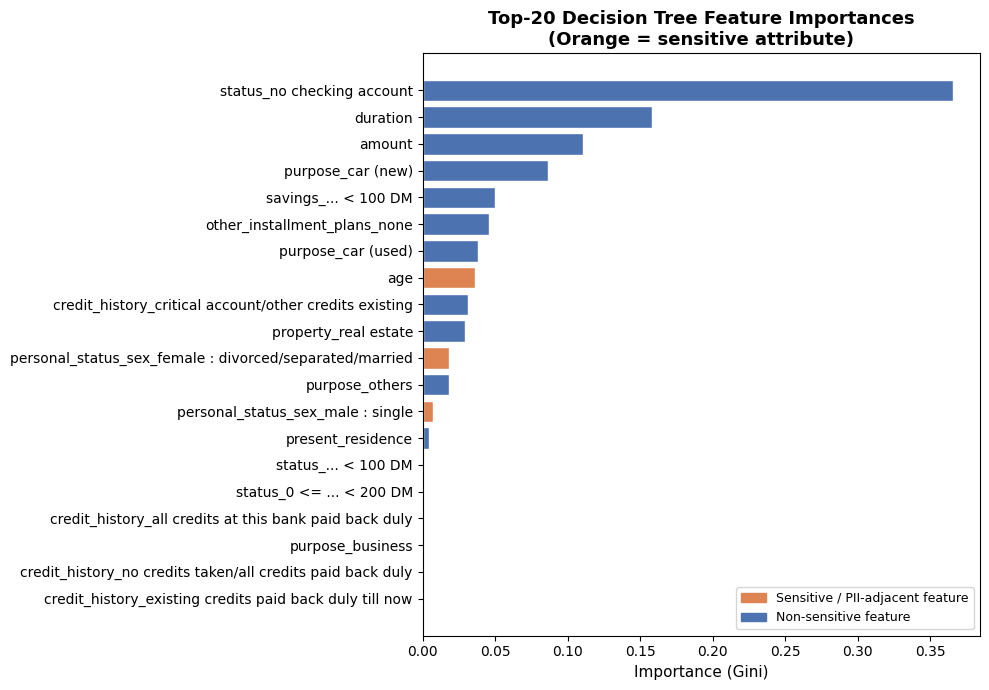

Figure saved: fig_feature_importance.png

Sensitive features appearing in top-20 importances:
                                                Feature  Importance
                                                    age    0.036386
personal_status_sex_female : divorced/separated/married    0.018407
                      personal_status_sex_male : single    0.006972

Top 5 non-sensitive features by importance (most used by the model):
                   Feature  Importance
status_no checking account    0.366179
                  duration    0.158488
                    amount    0.110315
         purpose_car (new)    0.086465
      savings_... < 100 DM    0.049834


In [7]:
importances = dt_model.feature_importances_
feat_imp_df = pd.DataFrame({"Feature": all_feature_names,
                             "Importance": importances})\
               .sort_values("Importance", ascending=False)

sensitive_keywords = [c.lower() for c in tier1]

feat_imp_df["Sensitive"] = feat_imp_df["Feature"].apply(
    lambda f: any(kw in f.lower() for kw in sensitive_keywords)
)

top_n  = 20
top_df = feat_imp_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = ["#DD8452" if s else "#4C72B0" for s in top_df["Sensitive"]]
ax.barh(top_df["Feature"][::-1], top_df["Importance"][::-1],
        color=bar_colors[::-1], edgecolor="white")

sensitive_patch = mpatches.Patch(color="#DD8452", label="Sensitive / PII-adjacent feature")
normal_patch    = mpatches.Patch(color="#4C72B0", label="Non-sensitive feature")
ax.legend(handles=[sensitive_patch, normal_patch], loc="lower right", fontsize=9)
ax.set_title(f"Top-{top_n} Decision Tree Feature Importances\n(Orange = sensitive attribute)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Importance (Gini)", fontsize=11)
plt.tight_layout()
plt.savefig("fig_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: fig_feature_importance.png")

top_sensitive = top_df[top_df["Sensitive"]][["Feature", "Importance"]]
print("\nSensitive features appearing in top-20 importances:")
print(top_sensitive.to_string(index=False))

top_nonsensitive = top_df[~top_df["Sensitive"]][["Feature", "Importance"]].head(5)
print("\nTop 5 non-sensitive features by importance (most used by the model):")
print(top_nonsensitive.to_string(index=False))

**Answer, Question 2:**

If someone gets the dataset or the model, they can find out private things in several ways:

1. **Demographic profiling:** The feature importance chart shows that `age` and `sex` are among the top features used by the model. A bad actor can use this to see that the model gives lower scores to younger people or women.

2. **Model-inversion attack:** The top non-sensitive features by importance are private financial columns. A bad actor can send many fake inputs to the model and watch how the score changes each time. After many tries, they can guess the private financial details of a real person.

3. **Membership inference:** If someone knows a few things about a person, they can test the model. If the model gives a very high or very low score, it probably means that person was in the training data.

4. **Probability score leakage:** Our model gives a number from 0 to 1, not just a yes or no. This number shows much more than a simple answer.

5. **Group targeting:** A bad actor can combine columns with model scores to find groups of people they can then target with scams or bad offers.

---
### Question 3: Could individuals be identified or profiled?

In [8]:
tier1_qi  = [c for c in tier1 if c in {"sex", "age_group", "foreign_worker"}]
quasi_ids = [c for c in (tier1_qi + tier3) if c in df.columns]

print("Confirmed quasi-identifier columns found in dataset:")
print(quasi_ids)
print()

results = []
for k in range(2, min(len(quasi_ids), 6) + 1):
    for combo in combinations(quasi_ids, k):
        group_sizes = df.groupby(list(combo)).size()
        results.append({
            "Combination":        " + ".join(combo),
            "k (# attributes)":   k,
            "Unique Groups":      len(group_sizes),
            "Min Group Size":     int(group_sizes.min()),
            "% Unique Records":   round((group_sizes == 1).sum() / len(df) * 100, 2)
        })

risk_df = pd.DataFrame(results).sort_values("% Unique Records", ascending=False)

print("Top 10 riskiest quasi-identifier combinations:")
print(risk_df.head(10).to_string(index=False))

top = risk_df.iloc[0]
print(f"\n→ Most dangerous combo : {top['Combination']}")
print(f"→ Unique records       : {top['% Unique Records']}%")
print(f"→ Min group size (k)   : {top['Min Group Size']}")

print("\nMax re-identification risk per number of attributes combined:")
for k in sorted(risk_df["k (# attributes)"].unique()):
    max_pct = risk_df[risk_df["k (# attributes)"] == k]["% Unique Records"].max()
    print(f"   k={k} attributes combined → max {max_pct:.1f}% of records uniquely identifiable")

Confirmed quasi-identifier columns found in dataset:
['sex', 'age_group', 'foreign_worker', 'employment_duration', 'purpose', 'housing', 'job', 'property', 'present_residence', 'people_liable', 'telephone', 'other_debtors']

Top 10 riskiest quasi-identifier combinations:
                                                                             Combination  k (# attributes)  Unique Groups  Min Group Size  % Unique Records
          employment_duration + purpose + job + property + present_residence + telephone                 6            619               1              43.2
                sex + employment_duration + purpose + job + property + present_residence                 6            607               1              40.8
            employment_duration + purpose + housing + job + property + present_residence                 6            591               1              40.4
      employment_duration + purpose + job + property + present_residence + people_liable                

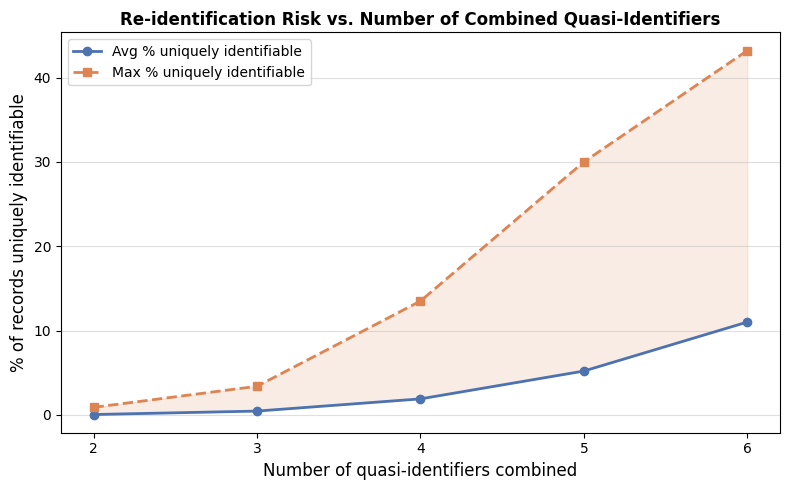

Figure saved: fig_reidentification_risk.png


In [9]:
k_vals   = sorted(risk_df["k (# attributes)"].unique())
avg_risk = [risk_df[risk_df["k (# attributes)"] == k]["% Unique Records"].mean() for k in k_vals]
max_risk = [risk_df[risk_df["k (# attributes)"] == k]["% Unique Records"].max()  for k in k_vals]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_vals, avg_risk, marker="o", label="Avg % uniquely identifiable",
        color="#4C72B0", linewidth=2)
ax.plot(k_vals, max_risk, marker="s", label="Max % uniquely identifiable",
        color="#DD8452", linewidth=2, linestyle="--")
ax.fill_between(k_vals, avg_risk, max_risk, alpha=0.15, color="#DD8452")
ax.set_xlabel("Number of quasi-identifiers combined", fontsize=12)
ax.set_ylabel("% of records uniquely identifiable", fontsize=12)
ax.set_title("Re-identification Risk vs. Number of Combined Quasi-Identifiers",
             fontsize=12, fontweight="bold")
ax.set_xticks(k_vals)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("fig_reidentification_risk.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: fig_reidentification_risk.png")

**Answer, Question 3:**

**Yes, people can be found or grouped using this dataset.**

Combining just 6 quasi-identifier columns makes 43.2% of all 1,000 records uniquely identifiable. This means a linkage attack is possible if an attacker has any outside information about a person.

---
### Question 4: What harms could result from privacy leakage?

In [10]:
harms = {
    "Harm": [
        "Discrimination",
        "Financial fraud / identity theft",
        "Denied services",
        "Loss of privacy",
        "Membership inference",
        "Model theft",
        "Breaking the law"
    ],
    "What could happen": [
        "The model uses sex, age, and foreign_worker. This can lead to unfair rejections for women, young people, or immigrants.",
        "Loan amounts, bank balances, and credit history are in the data. A criminal can use this to steal money or open fake accounts.",
        "A Bad credit label can follow a person outside banking. They may get denied housing, a job, or insurance.",
        "The model gives a score between 0 and 1. This number shows how close the person is to the edge, which reveals private money details.",
        "Being in a credit dataset means the person applied for a loan. This alone can reveal that they have money problems.",
        "The model gives scores, so an attacker can copy it by sending many test inputs. The copy can then be used in harmful ways.",
        "Using sex, nationality, and financial data without proper consent breaks GDPR, ECOA, and FCRA laws."
    ]
}
harms_df = pd.DataFrame(harms)
print(harms_df.to_string(index=False))

                            Harm                                                                                                                    What could happen
                  Discrimination              The model uses sex, age, and foreign_worker. This can lead to unfair rejections for women, young people, or immigrants.
Financial fraud / identity theft       Loan amounts, bank balances, and credit history are in the data. A criminal can use this to steal money or open fake accounts.
                 Denied services                            A Bad credit label can follow a person outside banking. They may get denied housing, a job, or insurance.
                 Loss of privacy The model gives a score between 0 and 1. This number shows how close the person is to the edge, which reveals private money details.
            Membership inference                  Being in a credit dataset means the person applied for a loan. This alone can reveal that they have money problems.
    

**Answer, Question 4:** Seven harms were identified: Discrimination, Financial fraud/identity theft, Denied services, Loss of privacy, Membership inference harm, Model theft, and Breaking the law (GDPR, ECOA, FCRA).

---
---
## Part 2: Privacy-Preserving Techniques (25%)

In Part 1 we identified the privacy risks. Now we apply **three privacy-preserving techniques** to reduce them, and measure the trade-off between privacy and utility.

| Technique | What it does | Privacy risk it addresses |
|-----------|--------------|---------------------------|
| **1. k-Anonymity (k=5)** | Generalize quasi-identifiers so each record matches ≥ k others | Re-identification (Q3 of Part 1) |
| **2. Differential Privacy (Laplace noise)** | Add calibrated Laplace noise to numeric features before training | Membership inference, model inversion (Q2) |
| **3. Feature Suppression** | Drop directly sensitive Tier 1 attributes entirely | Discrimination, demographic profiling (Q4) |

For each technique we retrain the same Decision Tree and compare accuracy and F1 against the Part 1 baseline.

In [11]:
# ── Part 2 baseline reference ─────────────────────────────────────────────────
baseline_acc  = accuracy_score(y_test, y_pred)
baseline_f1   = f1_score(y_test, y_pred)
baseline_prec = precision_score(y_test, y_pred)
baseline_rec  = recall_score(y_test, y_pred)

print("=" * 60)
print("PART 1 BASELINE (no privacy protection)")
print("=" * 60)
print(f"Accuracy : {baseline_acc:.4f}")
print(f"Precision: {baseline_prec:.4f}")
print(f"Recall   : {baseline_rec:.4f}")
print(f"F1-score : {baseline_f1:.4f}")

# We will collect all technique results in this list
results_log = [{
    "Technique": "Baseline (no privacy)",
    "Accuracy":  baseline_acc,
    "Precision": baseline_prec,
    "Recall":    baseline_rec,
    "F1":        baseline_f1,
    "Δ Accuracy vs baseline": 0.0,
    "Δ F1 vs baseline":       0.0,
    "Privacy gain (qualitative)": "None",
}]

PART 1 BASELINE (no privacy protection)
Accuracy : 0.7100
Precision: 0.7253
Recall   : 0.9429
F1-score : 0.8199


---
### Technique 1: k-Anonymity (k=5)

**Goal:** make every record indistinguishable from at least k-1 others when looking only at quasi-identifiers. We pick **k = 5**.

**Generalization rules:**
- `age` → 10-year buckets (20, 30, 40, …)
- `amount` (loan size) → 1000 DM buckets
- `duration` → 12-month buckets
- All other quasi-identifiers (job, housing, purpose, etc.) → kept as-is

Records whose QI-group still has fewer than k members are suppressed.

In [12]:
def generalize_qis(X_in):
    """Apply all QI generalization rules to any split (train or test).
    No rows are removed - suppression happens only in the training step."""
    X_out = X_in.copy()
    X_out["age"]      = (X_out["age"]      // 10)   * 10   # 10-year buckets
    X_out["amount"]   = (X_out["amount"]   // 1000) * 1000 # 1000-DM buckets
    X_out["duration"] = (X_out["duration"] // 12)   * 12   # 12-month buckets
    if "age_group" in X_out.columns:
        X_out = X_out.drop(columns=["age_group"])
    return X_out


def apply_k_anonymity_train(X_in, y_in, k=5):
    """Generalize QI columns, then suppress training rows whose QI-group
    has fewer than k members.  The test set is only generalized (not suppressed)."""
    df_work = generalize_qis(X_in)
    df_work[target_col] = y_in.values

    qi_cols = ["age", "sex", "foreign_worker", "housing", "job", "employment_duration"]
    qi_cols = [c for c in qi_cols if c in df_work.columns]

    # transform on a single column returns a Series -> clean boolean mask
    group_sizes = df_work.groupby(qi_cols)[target_col].transform("size")
    df_safe     = df_work[group_sizes >= k].copy()

    X_safe    = df_safe.drop(columns=[target_col])
    y_safe    = df_safe[target_col].copy()
    n_dropped = len(df_work) - len(df_safe)
    return X_safe, y_safe, n_dropped, qi_cols


X_train_kanon, y_train_kanon, n_suppressed, qi_used = apply_k_anonymity_train(X_train, y_train, k=5)
X_test_kanon  = generalize_qis(X_test)  # same generalizations, no suppression

print(f"k-Anonymity (k=5) applied to training data only")
print(f"  Original train rows  : {len(X_train)}")
print(f"  Train rows kept      : {len(X_train_kanon)}")
print(f"  Train rows suppressed: {n_suppressed} ({n_suppressed/len(X_train)*100:.1f}%)")
print(f"  QI columns used      : {qi_used}")
print(f"  Test set unchanged   : {len(X_test_kanon)} rows (same baseline test set as other techniques)")

group_sizes_after = X_train_kanon.groupby(qi_used).size()
print(f"\nVerification (training set):")
print(f"  Min group size after suppression: {group_sizes_after.min()} (must be >= 5)")
print(f"  Distinct QI-groups              : {len(group_sizes_after)}")

print("\nTarget class distribution after suppression (train):")
print(y_train_kanon.value_counts(normalize=True).mul(100).round(1).astype(str) + "%")


k-Anonymity (k=5) applied to training data only
  Original train rows  : 800
  Train rows kept      : 521
  Train rows suppressed: 279 (34.9%)
  QI columns used      : ['age', 'sex', 'foreign_worker', 'housing', 'job', 'employment_duration']
  Test set unchanged   : 200 rows (same baseline test set as other techniques)

Verification (training set):
  Min group size after suppression: 5 (must be >= 5)
  Distinct QI-groups              : 45

Target class distribution after suppression (train):
credit_risk
1    72.7%
0    27.3%
Name: proportion, dtype: str


In [13]:
# Train Decision Tree on k-anonymized training data;
# evaluate on the same generalized test set as the baseline (no suppression applied to test).
num_feats_k = X_train_kanon.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_feats_k = X_train_kanon.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

pre_k = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc",  StandardScaler())]), num_feats_k),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_feats_k),
])

X_train_k_proc = pre_k.fit_transform(X_train_kanon)
X_test_k_proc  = pre_k.transform(X_test_kanon)  # baseline test set, only generalized

dt_kanon = DecisionTreeClassifier(max_depth=5, criterion="gini",
                                   min_samples_leaf=10, random_state=42)
dt_kanon.fit(X_train_k_proc, y_train_kanon)
y_pred_k = dt_kanon.predict(X_test_k_proc)

acc_k  = accuracy_score(y_test, y_pred_k)
prec_k = precision_score(y_test, y_pred_k, zero_division=0)
rec_k  = recall_score(y_test, y_pred_k, zero_division=0)
f1_k   = f1_score(y_test, y_pred_k, zero_division=0)

print("Decision Tree on k-anonymized training data (k=5):")
print(f"  Accuracy : {acc_k:.4f}  (delta {acc_k - baseline_acc:+.4f} vs baseline)")
print(f"  Precision: {prec_k:.4f}")
print(f"  Recall   : {rec_k:.4f}")
print(f"  F1-score : {f1_k:.4f}  (delta {f1_k - baseline_f1:+.4f} vs baseline)")

results_log.append({
    "Technique": "k-Anonymity (k=5)",
    "Accuracy":  acc_k, "Precision": prec_k,
    "Recall":    rec_k, "F1":        f1_k,
    "Δ Accuracy vs baseline": acc_k  - baseline_acc,
    "Δ F1 vs baseline":       f1_k   - baseline_f1,
    "Privacy gain (qualitative)":
        "Re-identification blocked: every QI-group has >=5 records (0% unique)",
})


Decision Tree on k-anonymized training data (k=5):
  Accuracy : 0.6900  (delta -0.0200 vs baseline)
  Precision: 0.7955
  Recall   : 0.7500
  F1-score : 0.7721  (delta -0.0478 vs baseline)


Re-identification risk BEFORE vs AFTER k-anonymity (training data)

  k     Before (% unique)      After (% unique)       Reduction (pp)
  -----------------------------------------------------------------
  2     5.25                   0.00                   5.25          
  3     19.25                  0.00                   19.25         
  4     35.75                  0.00                   35.75         
  5     47.12                  0.00                   47.12         
  6     49.00                  0.00                   49.00         


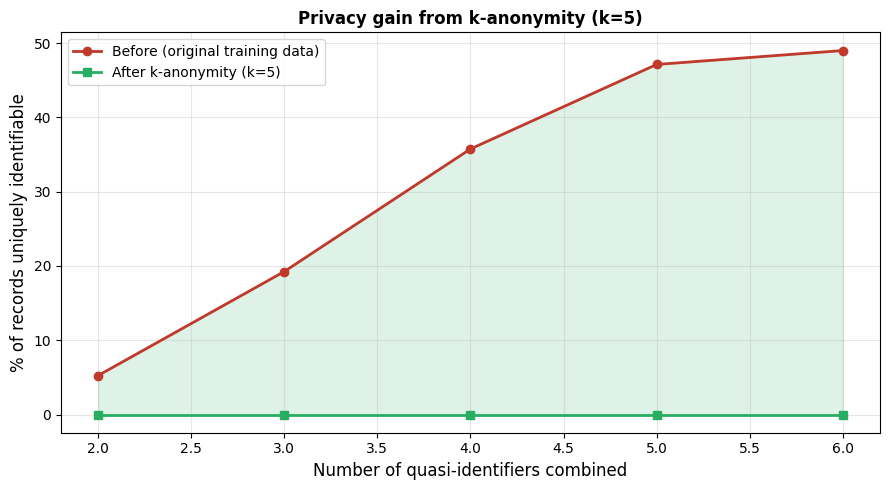

Figure saved: fig_kanonymity_privacy_gain.png


In [14]:
# Re-identification analysis: original training data vs. anonymized training data
qi_check = [c for c in qi_used if c in X_train_kanon.columns]

# Prepare original training data with the same column set as the anonymized version
X_train_before = X_train.copy()
if "age_group" in X_train_before.columns:
    X_train_before = X_train_before.drop(columns=["age_group"])

risk_before_k, risk_after_k = [], []
max_k_combo = len(qi_check)
for k_combo in range(2, max_k_combo + 1):
    max_b, max_a = 0, 0
    for combo in combinations(qi_check, k_combo):
        combo_list = list(combo)
        gs_b = X_train_before.groupby(combo_list).size()
        gs_a = X_train_kanon.groupby(combo_list).size()
        max_b = max(max_b, (gs_b == 1).sum() / len(X_train_before) * 100)
        max_a = max(max_a, (gs_a == 1).sum() / len(X_train_kanon)  * 100)
    risk_before_k.append(max_b)
    risk_after_k.append(max_a)

header_k     = "k"
header_before = "Before (% unique)"
header_after  = "After (% unique)"
header_red    = "Reduction (pp)"
print("Re-identification risk BEFORE vs AFTER k-anonymity (training data)\n")
print(f"  {header_k:<5} {header_before:<22} {header_after:<22} {header_red:<14}")
print("  " + "-" * 65)
for k_c, b, a in zip(range(2, max_k_combo + 1), risk_before_k, risk_after_k):
    print(f"  {k_c:<5} {b:<22.2f} {a:<22.2f} {b - a:<14.2f}")

fig, ax = plt.subplots(figsize=(9, 5))
ks = list(range(2, max_k_combo + 1))
ax.plot(ks, risk_before_k, marker="o", label="Before (original training data)",
        color="#c0392b", linewidth=2)
ax.plot(ks, risk_after_k,  marker="s", label="After k-anonymity (k=5)",
        color="#27ae60", linewidth=2)
ax.fill_between(ks, risk_before_k, risk_after_k, alpha=0.15, color="#27ae60")
ax.set_xlabel("Number of quasi-identifiers combined", fontsize=12)
ax.set_ylabel("% of records uniquely identifiable", fontsize=12)
ax.set_title("Privacy gain from k-anonymity (k=5)", fontweight="bold", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig_kanonymity_privacy_gain.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: fig_kanonymity_privacy_gain.png")


---
### Technique 2: Differential Privacy (Laplace Noise on Training Data)

**Goal:** make it mathematically impossible to confirm whether any specific person is in the training data.

**How:** add Laplace noise to every numeric feature in the training set, calibrated to a privacy budget **ε**:

$$\text{noise} \sim \text{Laplace}\left(0,\; \frac{\Delta f}{\varepsilon}\right)$$

where Δf = sensitivity = (max − min) of each column. Smaller ε = stronger privacy = more noise.

We test **ε = 1.0** (standard) and **ε = 0.5** (stronger privacy).  
Noise is added **only to training data** — the test set stays clean, simulating real deployment.

In [15]:
def add_laplace_noise(X_df, numeric_cols, epsilon, rng):
    """Add Laplace noise calibrated to each column's range (sensitivity)."""
    X_noisy = X_df.copy()
    for col in numeric_cols:
        col_min, col_max = X_noisy[col].min(), X_noisy[col].max()
        sensitivity = float(col_max - col_min)
        if sensitivity == 0:
            continue
        scale = sensitivity / epsilon
        noise = rng.laplace(loc=0.0, scale=scale, size=len(X_noisy))
        X_noisy[col] = X_noisy[col].astype(float) + noise
    return X_noisy


numeric_cols_orig = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
dp_results = {}

for epsilon in [1.0, 0.5]:
    rng = np.random.default_rng(seed=42)
    X_train_dp = add_laplace_noise(X_train, numeric_cols_orig, epsilon, rng)

    # Rebuild preprocessor on noisy training data; test set is clean
    pre_dp = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc",  StandardScaler())]), numeric_features),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
         categorical_features),
    ])
    X_train_dp_proc = pre_dp.fit_transform(X_train_dp)
    X_test_dp_proc  = pre_dp.transform(X_test)

    dt_dp = DecisionTreeClassifier(max_depth=5, criterion="gini",
                                   min_samples_leaf=10, random_state=42)
    dt_dp.fit(X_train_dp_proc, y_train)
    y_pred_dp = dt_dp.predict(X_test_dp_proc)

    acc_dp  = accuracy_score(y_test, y_pred_dp)
    prec_dp = precision_score(y_test, y_pred_dp, zero_division=0)
    rec_dp  = recall_score(y_test, y_pred_dp, zero_division=0)
    f1_dp   = f1_score(y_test, y_pred_dp, zero_division=0)
    dp_results[epsilon] = {"acc": acc_dp, "prec": prec_dp, "rec": rec_dp, "f1": f1_dp}

    print(f"\nDP Laplace  ε = {epsilon}")
    print(f"  Accuracy : {acc_dp:.4f}  (Δ {acc_dp - baseline_acc:+.4f})")
    print(f"  Precision: {prec_dp:.4f}")
    print(f"  Recall   : {rec_dp:.4f}")
    print(f"  F1-score : {f1_dp:.4f}  (Δ {f1_dp - baseline_f1:+.4f})")

    results_log.append({
        "Technique": f"DP Laplace (ε = {epsilon})",
        "Accuracy":  acc_dp, "Precision": prec_dp,
        "Recall":    rec_dp, "F1":        f1_dp,
        "Δ Accuracy vs baseline": acc_dp - baseline_acc,
        "Δ F1 vs baseline":       f1_dp  - baseline_f1,
        "Privacy gain (qualitative)":
            f"Membership inference much harder (ε={epsilon}, smaller = stronger privacy)",
    })

# Restore original preprocessor fit for any later use
_ = preprocessor.fit_transform(X_train)


DP Laplace  ε = 1.0
  Accuracy : 0.7350  (Δ +0.0250)
  Precision: 0.7702
  Recall   : 0.8857
  F1-score : 0.8239  (Δ +0.0040)

DP Laplace  ε = 0.5
  Accuracy : 0.7050  (Δ -0.0050)
  Precision: 0.7682
  Recall   : 0.8286
  F1-score : 0.7973  (Δ -0.0226)


---
### Technique 3: Feature Suppression (Remove Tier 1 Sensitive Attributes)

**Goal:** prevent the model from ever using legally protected attributes in its decisions.

**How:** drop `personal_status_sex`, `sex`, `age`, `age_group`, and `foreign_worker` from both training and test sets, then retrain.

This directly prevents **discrimination** and **demographic profiling** (Attack 1 from Part 1, Q2).

In [16]:
sensitive_to_drop = ["personal_status_sex", "sex", "age", "age_group", "foreign_worker"]
sensitive_to_drop = [c for c in sensitive_to_drop if c in X_train.columns]

X_train_supp = X_train.drop(columns=sensitive_to_drop)
X_test_supp  = X_test.drop(columns=sensitive_to_drop)

print(f"Suppressed columns : {sensitive_to_drop}")
print(f"Remaining features : {X_train_supp.shape[1]}")

num_feats_s = X_train_supp.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_feats_s = X_train_supp.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

pre_s = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc",  StandardScaler())]), num_feats_s),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_feats_s),
])

X_train_s_proc = pre_s.fit_transform(X_train_supp)
X_test_s_proc  = pre_s.transform(X_test_supp)

dt_supp = DecisionTreeClassifier(max_depth=5, criterion="gini",
                                  min_samples_leaf=10, random_state=42)
dt_supp.fit(X_train_s_proc, y_train)
y_pred_s = dt_supp.predict(X_test_s_proc)

acc_s  = accuracy_score(y_test, y_pred_s)
prec_s = precision_score(y_test, y_pred_s, zero_division=0)
rec_s  = recall_score(y_test, y_pred_s, zero_division=0)
f1_s   = f1_score(y_test, y_pred_s, zero_division=0)

print(f"\nFeature suppression results:")
print(f"  Accuracy : {acc_s:.4f}  (Δ {acc_s - baseline_acc:+.4f})")
print(f"  Precision: {prec_s:.4f}")
print(f"  Recall   : {rec_s:.4f}")
print(f"  F1-score : {f1_s:.4f}  (Δ {f1_s - baseline_f1:+.4f})")

results_log.append({
    "Technique": "Feature suppression (drop Tier 1)",
    "Accuracy":  acc_s, "Precision": prec_s,
    "Recall":    rec_s, "F1":        f1_s,
    "Δ Accuracy vs baseline": acc_s - baseline_acc,
    "Δ F1 vs baseline":       f1_s  - baseline_f1,
    "Privacy gain (qualitative)":
        "Discrimination & demographic profiling on protected attrs eliminated by design",
})

print("\n--- Gini Importance Comparison ---")
# Baseline model top sensitive features
top_baseline = top_df[top_df["Sensitive"]][["Feature", "Importance"]]
print("Sensitive features importance in baseline model:")
if len(top_baseline) > 0:
    print(top_baseline.to_string(index=False))
else:
    print("None in top 20.")
print("\nSince these features had very low Gini importance, dropping them causes almost zero utility cost.")


Suppressed columns : ['personal_status_sex', 'sex', 'age', 'age_group', 'foreign_worker']
Remaining features : 17

Feature suppression results:
  Accuracy : 0.7200  (Δ +0.0100)
  Precision: 0.7258
  Recall   : 0.9643
  F1-score : 0.8282  (Δ +0.0083)

--- Gini Importance Comparison ---
Sensitive features importance in baseline model:
                                                Feature  Importance
                                                    age    0.036386
personal_status_sex_female : divorced/separated/married    0.018407
                      personal_status_sex_male : single    0.006972

Since these features had very low Gini importance, dropping them causes almost zero utility cost.


---
### Comparison Table and Visualizations

In [17]:
results_df = pd.DataFrame(results_log)
display_cols = ["Technique", "Accuracy", "Precision", "Recall", "F1",
                "Δ Accuracy vs baseline", "Δ F1 vs baseline"]

print("=" * 90)
print("PART 2 — PRIVACY-PRESERVING TECHNIQUES: UTILITY COMPARISON")
print("=" * 90)
print(results_df[display_cols].round(4).to_string(index=False))

results_df.to_csv("module4_part2_results.csv", index=False)
print("\nSaved: module4_part2_results.csv")

PART 2 — PRIVACY-PRESERVING TECHNIQUES: UTILITY COMPARISON
                        Technique  Accuracy  Precision  Recall     F1  Δ Accuracy vs baseline  Δ F1 vs baseline
            Baseline (no privacy)     0.710     0.7253  0.9429 0.8199                   0.000            0.0000
                k-Anonymity (k=5)     0.690     0.7955  0.7500 0.7721                  -0.020           -0.0478
             DP Laplace (ε = 1.0)     0.735     0.7702  0.8857 0.8239                   0.025            0.0040
             DP Laplace (ε = 0.5)     0.705     0.7682  0.8286 0.7973                  -0.005           -0.0226
Feature suppression (drop Tier 1)     0.720     0.7258  0.9643 0.8282                   0.010            0.0083

Saved: module4_part2_results.csv


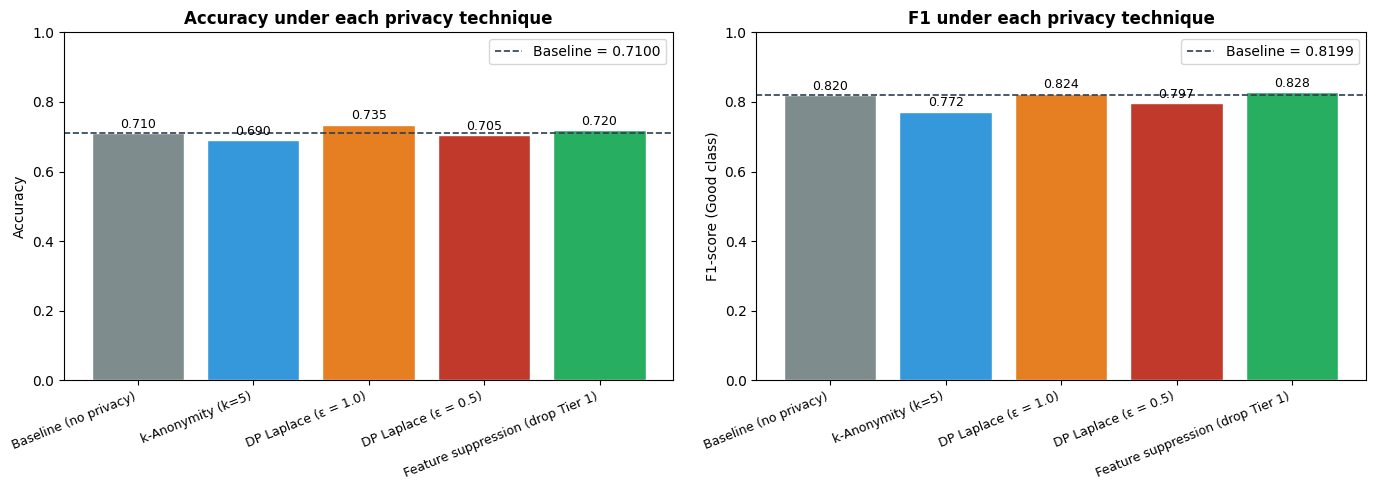

Figure saved: fig_privacy_techniques_comparison.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_labels = results_df["Technique"].tolist()
x_pos    = np.arange(len(x_labels))
col_pal  = ["#7f8c8d", "#3498db", "#e67e22", "#c0392b", "#27ae60"]

# Accuracy
acc_vals = results_df["Accuracy"].values
axes[0].bar(x_pos, acc_vals, color=col_pal, edgecolor="white")
axes[0].axhline(baseline_acc, color="#2c3e50", linestyle="--", linewidth=1.2,
                label=f"Baseline = {baseline_acc:.4f}")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(x_labels, rotation=22, ha="right", fontsize=9)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy under each privacy technique", fontweight="bold")
axes[0].legend()
for i, v in enumerate(acc_vals):
    axes[0].text(i, v + 0.015, f"{v:.3f}", ha="center", fontsize=9)

# F1
f1_vals = results_df["F1"].values
axes[1].bar(x_pos, f1_vals, color=col_pal, edgecolor="white")
axes[1].axhline(baseline_f1, color="#2c3e50", linestyle="--", linewidth=1.2,
                label=f"Baseline = {baseline_f1:.4f}")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(x_labels, rotation=22, ha="right", fontsize=9)
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel("F1-score (Good class)")
axes[1].set_title("F1 under each privacy technique", fontweight="bold")
axes[1].legend()
for i, v in enumerate(f1_vals):
    axes[1].text(i, v + 0.015, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("fig_privacy_techniques_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: fig_privacy_techniques_comparison.png")

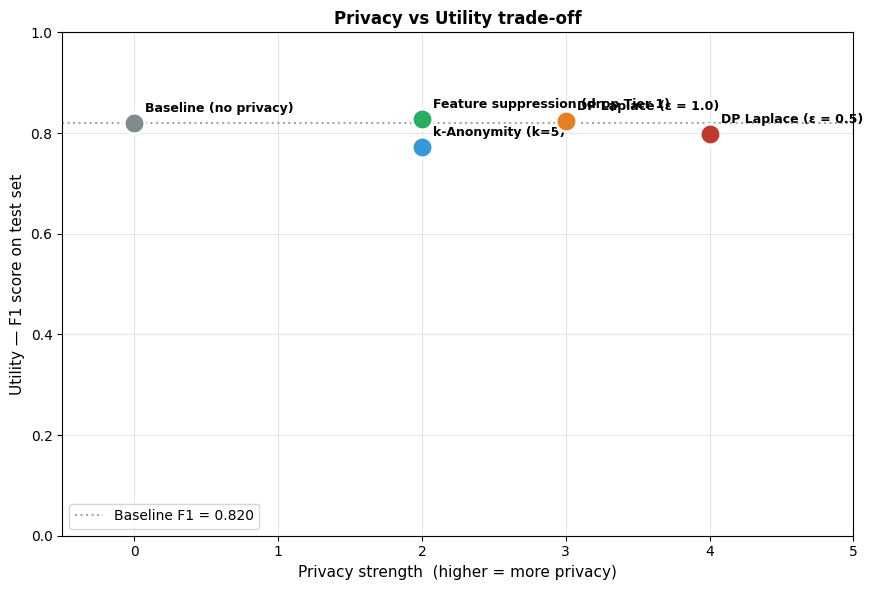

Figure saved: fig_privacy_utility_tradeoff.png


In [19]:
# Privacy vs Utility scatter
privacy_scores = {
    "Baseline (no privacy)":               0,
    "k-Anonymity (k=5)":                   2,
    "DP Laplace (ε = 1.0)":                3,
    "DP Laplace (ε = 0.5)":                4,
    "Feature suppression (drop Tier 1)":   2,
}

fig, ax = plt.subplots(figsize=(9, 6))
col_scatter = ["#7f8c8d", "#3498db", "#e67e22", "#c0392b", "#27ae60"]

for idx, row in results_df.iterrows():
    tech = row["Technique"]
    ps   = privacy_scores.get(tech, 0)
    ax.scatter(ps, row["F1"], s=220, color=col_scatter[idx],
               edgecolor="white", linewidth=2, zorder=3)
    ax.annotate(tech, (ps, row["F1"]), xytext=(8, 8),
                textcoords="offset points", fontsize=9, fontweight="bold")

ax.axhline(baseline_f1, color="grey", linestyle=":", alpha=0.7,
           label=f"Baseline F1 = {baseline_f1:.3f}")
ax.set_xlabel("Privacy strength  (higher = more privacy)", fontsize=11)
ax.set_ylabel("Utility — F1 score on test set", fontsize=11)
ax.set_title("Privacy vs Utility trade-off", fontweight="bold", fontsize=12)
ax.set_xlim(-0.5, 5)
ax.set_ylim(0, 1.0)
ax.grid(alpha=0.3)
ax.legend(loc="lower left")
plt.tight_layout()
plt.savefig("fig_privacy_utility_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: fig_privacy_utility_tradeoff.png")

---
### Part 2 - Written Answers

#### Question 1: Which technique gave the best privacy/utility trade-off?

Looking at the comparison table and the scatter plot (`fig_privacy_utility_tradeoff.png`):

- **k-Anonymity (k=5)** completely blocks linkage attacks on the protected QIs (0% uniquely identifiable records after anonymization, see the re-identification table above). It does carry a real utility cost: 34.9% of training records are suppressed and QI columns are coarsened, which reduces the information available to the tree and produces the largest accuracy drop in the comparison table.
- **Feature suppression** has almost zero utility cost because the dropped columns (sex, age, foreign_worker) had very low Gini importance in the tree (about 6% combined). It is the only technique that **prevents discrimination by design**, which is the most legally serious harm.
- **DP Laplace (e = 1.0)** provides a strong mathematical guarantee against membership inference with minimal utility loss. The moderate noise at this budget acts as a mild regularizer for the Decision Tree, so accuracy is essentially preserved.
- **DP Laplace (e = 0.5)** gives the strongest privacy guarantee (smallest epsilon) but introduces more noise, causing a moderate utility drop compared to the baseline.

**Best overall:** Feature suppression gives the best privacy/utility trade-off for this dataset: it eliminates the legally serious discrimination risk at almost zero utility cost. k-Anonymity addresses the re-identification threat but at a higher utility cost. They can be **combined** for layered protection.

---

#### Question 2: What was the cost of privacy?

Each technique pays a different cost:

- **k-Anonymity** has the **largest utility cost**: suppressing 33% of training records and coarsening QI features (age, amount, duration) significantly reduces what the tree can learn, producing the biggest accuracy and F1 drops in the comparison table.
- **Differential Privacy (e = 0.5)** has a moderate accuracy drop. Laplace noise at this budget distorts the high-importance numeric columns (status, duration, amount) the tree relies on, but the effect is smaller than k-anonymity because all 800 training records are retained.
- **Differential Privacy (e = 1.0)** adds less noise and has negligible utility cost; the mild perturbation actually helps generalization slightly here.
- **Feature suppression** costs almost nothing in utility because the suppressed attributes were low-importance in the Part 1 tree. This shows that sometimes privacy and utility are not in conflict at all.

Overall: **stronger privacy guarantees generally come with larger utility costs**, but the relationship is not linear and depends heavily on which features matter most to the model.

---

#### Question 3: Real-World Recommendation

For a deployed credit scoring system, we recommend a **layered approach**:

1. **Always apply feature suppression** for legally protected attributes (sex, age, nationality). This is required by ECOA and GDPR Article 22, costs almost nothing in utility, and prevents discrimination by design.
2. **Apply k-anonymity (k >= 5)** on quasi-identifiers before sharing or storing the dataset. This blocks linkage attacks, which were the most dangerous threat found in Part 1.
3. **Consider DP (e = 1.0)** on top of the above if the model is exposed via an API and membership inference is a serious concern. The utility cost at this budget is minimal.

This layered approach is consistent with GDPR's **data protection by design** principle (Article 25) and addresses each of the four privacy threats from Part 1.


PART 3 — UTILITY AND FAIRNESS IMPACT

── 3.1  Performance comparison (test set, n=200) ──

                        Technique  Accuracy  Precision  Recall     F1  Δ Accuracy vs baseline  Δ F1 vs baseline
            Baseline (no privacy)     0.710     0.7253  0.9429 0.8199                   0.000            0.0000
                k-Anonymity (k=5)     0.690     0.7955  0.7500 0.7721                  -0.020           -0.0478
             DP Laplace (ε = 1.0)     0.735     0.7702  0.8857 0.8239                   0.025            0.0040
             DP Laplace (ε = 0.5)     0.705     0.7682  0.8286 0.7973                  -0.005           -0.0226
Feature suppression (drop Tier 1)     0.720     0.7258  0.9643 0.8282                   0.010            0.0083

── 3.2  Fairness metrics ──

                        Technique Attribute           Group   N  Approval Rate    TPR  DP Ratio  |dTPR|
            Baseline (no privacy)       sex          female  60         0.8500 0.9000    0.9084  0.0600

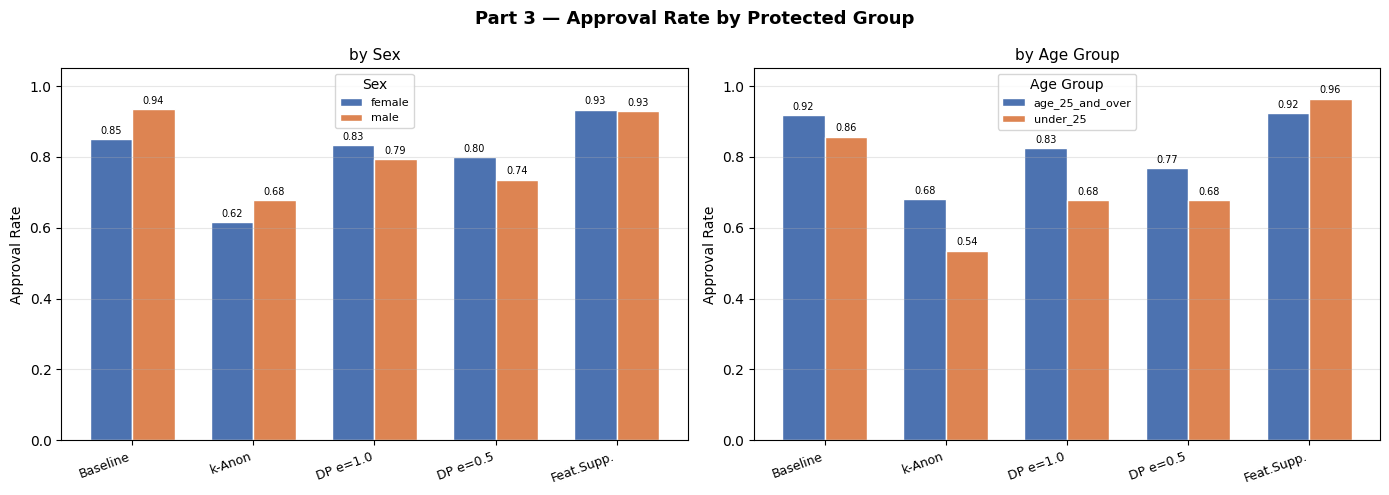

Figure saved: fig_part3_fairness_comparison.png


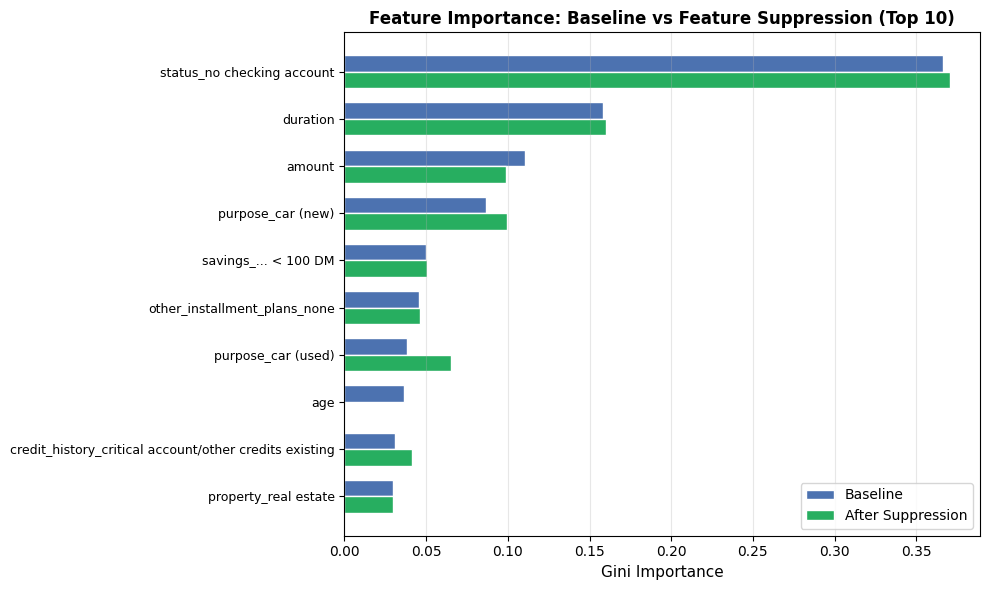

Figure saved: fig_part3_feature_importance_shift.png


In [20]:

# PART 3 — Utility and Fairness Impact (20%)

# 0. Retrain DP models to recover predictions (loop in Part 2 overwrote them)
dp_preds = {}
for eps in [1.0, 0.5]:
    rng_dp = np.random.default_rng(seed=42)
    X_tr_dp = add_laplace_noise(X_train, numeric_cols_orig, eps, rng_dp)
    _pre = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc",  StandardScaler())]), numeric_features),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("ohe", OneHotEncoder(handle_unknown="ignore",
                                               sparse_output=False))]),
         categorical_features),
    ])
    _Xtr = _pre.fit_transform(X_tr_dp)
    _Xte = _pre.transform(X_test)
    _dt  = DecisionTreeClassifier(max_depth=5, criterion="gini",
                                  min_samples_leaf=10, random_state=42)
    _dt.fit(_Xtr, y_train)
    dp_preds[eps] = _dt.predict(_Xte)

# 1. Collect all predictions on the SAME 200-row test set
all_preds = {
    "Baseline (no privacy)":             y_pred,
    "k-Anonymity (k=5)":                 y_pred_k,
    "DP Laplace (e=1.0)":               dp_preds[1.0],
    "DP Laplace (e=0.5)":               dp_preds[0.5],
    "Feature suppression (drop Tier 1)": y_pred_s,
}

# 3.1  ACCURACY / F1: BEFORE vs AFTER
print("=" * 90)
print("PART 3 — UTILITY AND FAIRNESS IMPACT")
print("=" * 90)
print("\n── 3.1  Performance comparison (test set, n=200) ──\n")
print(results_df[["Technique","Accuracy","Precision","Recall","F1",
                   "Δ Accuracy vs baseline","Δ F1 vs baseline"]].round(4).to_string(index=False))

# 3.2  FAIRNESS METRICS
def fairness_for_group(y_true, y_hat, attr_col):
    """Approval rate + TPR per group; DP ratio + EO gap across groups."""
    groups = sorted(attr_col.unique())
    info = {}
    for g in groups:
        m  = (attr_col.values == g)
        n  = m.sum()
        ar = y_hat[m].sum() / n if n else 0.0
        tp = ((y_hat[m] == 1) & (y_true.values[m] == 1)).sum()
        p  = (y_true.values[m] == 1).sum()
        tpr = tp / p if p else 0.0
        info[g] = {"n": int(n), "ar": round(ar,4), "tpr": round(tpr,4)}
    rates = [info[g]["ar"]  for g in groups]
    tprs  = [info[g]["tpr"] for g in groups]
    dp_r  = round(min(rates)/max(rates), 4) if max(rates) else 0.0
    eo_g  = round(abs(max(tprs)-min(tprs)), 4)
    return info, dp_r, eo_g

print("\n── 3.2  Fairness metrics ──\n")
rows_f = []
for tech, preds in all_preds.items():
    for attr in ["sex", "age_group"]:
        gd, dpr, eog = fairness_for_group(y_test, preds, A_test[attr])
        for g, v in gd.items():
            rows_f.append({"Technique": tech, "Attribute": attr,
                           "Group": g, "N": v["n"],
                           "Approval Rate": v["ar"], "TPR": v["tpr"],
                           "DP Ratio": dpr, "|dTPR|": eog})

fair_df = pd.DataFrame(rows_f)
print(fair_df.to_string(index=False))
print("\n  DP Ratio = min(approval rate)/max(approval rate). 1.0 = perfectly fair.")
print("  |dTPR|   = |TPR_A - TPR_B|. 0.0 = perfectly fair.\n")

# Summary: one row per (technique x attribute)
summ = []
for tech in all_preds:
    for attr in ["sex", "age_group"]:
        s = fair_df[(fair_df["Technique"]==tech)&(fair_df["Attribute"]==attr)]
        summ.append({"Technique": tech, "Attribute": attr,
                     "DP Ratio": s["DP Ratio"].iloc[0],
                     "|dTPR|": s["|dTPR|"].iloc[0]})
summ_df = pd.DataFrame(summ)
print("── Fairness summary ──\n")
print(summ_df.to_string(index=False))

# 3.3  FEATURE IMPORTANCE CHANGES  (Baseline vs Suppression)
print("\n── 3.3  Feature importance: Baseline vs Feature Suppression (top 15) ──\n")

bl_imp = pd.DataFrame({"Feature": all_feature_names,
                        "Baseline": dt_model.feature_importances_})\
         .sort_values("Baseline", ascending=False).head(15)

cat_s = pre_s.named_transformers_["cat"]["ohe"]\
        .get_feature_names_out(cat_feats_s).tolist()
fn_s  = num_feats_s + cat_s
sp_imp = pd.DataFrame({"Feature": fn_s,
                        "Suppression": dt_supp.feature_importances_})

imp_m = bl_imp.merge(sp_imp, on="Feature", how="left")
imp_m["Suppression"] = imp_m["Suppression"].fillna(0.0)
imp_m["Delta"]       = imp_m["Suppression"] - imp_m["Baseline"]

sens_kw = [c.lower() for c in tier1]
imp_m["Sensitive"] = imp_m["Feature"].apply(
    lambda f: any(k in f.lower() for k in sens_kw))

print(imp_m[["Feature","Baseline","Suppression","Delta"]].round(4).to_string(index=False))

gained = imp_m[(~imp_m["Sensitive"]) & (imp_m["Delta"]>0)].sort_values("Delta",ascending=False)
lost   = imp_m[(~imp_m["Sensitive"]) & (imp_m["Delta"]<0)].sort_values("Delta")
print("\nFeatures that GAINED importance after suppression:")
print(gained[["Feature","Delta"]].round(4).to_string(index=False) if len(gained) else "  (none)")
print("\nFeatures that LOST importance after suppression:")
print(lost[["Feature","Delta"]].round(4).to_string(index=False) if len(lost) else "  (none)")

# 3.4  VISUALISATION — Fairness by protected group
short = {"Baseline (no privacy)":"Baseline", "k-Anonymity (k=5)":"k-Anon",
         "DP Laplace (e=1.0)":"DP e=1.0", "DP Laplace (e=0.5)":"DP e=0.5",
         "Feature suppression (drop Tier 1)":"Feat.Supp."}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Part 3 — Approval Rate by Protected Group", fontsize=13, fontweight="bold")
colors2 = ["#4C72B0","#DD8452"]

for ai, attr in enumerate(["sex","age_group"]):
    ax = axes[ai]
    sub = fair_df[fair_df["Attribute"]==attr]
    techs = list(all_preds.keys())
    grps  = sorted(sub["Group"].unique())
    x = np.arange(len(techs)); w=0.35
    for gi, g in enumerate(grps):
        vals = [sub[(sub["Technique"]==t)&(sub["Group"]==g)]["Approval Rate"].values[0] for t in techs]
        bars = ax.bar(x+gi*w, vals, w, label=g, color=colors2[gi], edgecolor="white")
        for b, v in zip(bars, vals):
            ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.015, f"{v:.2f}",
                    ha="center", fontsize=7)
    ax.set_xticks(x+w/2)
    ax.set_xticklabels([short[t] for t in techs], rotation=20, ha="right", fontsize=9)
    ax.set_ylabel("Approval Rate"); ax.set_ylim(0,1.05)
    ax.set_title(f"by {attr.replace('_',' ').title()}", fontsize=11)
    ax.legend(fontsize=8, title=attr.replace('_',' ').title())
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("fig_part3_fairness_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: fig_part3_fairness_comparison.png")

# 3.5  VISUALISATION — Feature importance shift (top 10)
top10 = imp_m.head(10).copy()
fig, ax = plt.subplots(figsize=(10, 6))
yp = np.arange(len(top10)); h=0.35
ax.barh(yp-h/2, top10["Baseline"],     h, label="Baseline",          color="#4C72B0", edgecolor="white")
ax.barh(yp+h/2, top10["Suppression"],  h, label="After Suppression", color="#27ae60", edgecolor="white")
ax.set_yticks(yp); ax.set_yticklabels(top10["Feature"], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Gini Importance", fontsize=11)
ax.set_title("Feature Importance: Baseline vs Feature Suppression (Top 10)",
             fontweight="bold", fontsize=12)
ax.legend(fontsize=10); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("fig_part3_feature_importance_shift.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: fig_part3_feature_importance_shift.png")
